# Guided Numeric Exploration — COVID-19 Statistics (200 Rows)
_A short teaching panel — identities, rates, and within-country outcome checks_

***

**Programming Language:** Python in the Jupyter Notebook Environment

**Dataset:** [harshadapatil31/covid-19-statistics](https://www.kaggle.com/datasets/harshadapatil31/covid-19-statistics)

**Style counterpart:** [Guided Numeric and Text Exploration — E-Commerce](https://www.kaggle.com/code/nicapotato/guided-numeric-and-text-exploration-e-commerce)

**Code Navigation:** <br>
In the code, text after hashtags (`#`) are supportive explanations, not executed as code.

***


# Tables of Content:

**1. [Introduction](#Introduction)** <br>
**2. [Setup and Data Peek](#Setup)** <br>
**3. [Univariate & Rate Norms](#Univariate)** <br>
**4. [Faceted Time Series](#TimeSeries)** <br>
**5. [Vaccination vs Outcomes](#Vax)** <br>
**6. [What It Means — Working Synthesis](#Synthesis)** <br>

# **1. Introduction:** <a id="Introduction"></a> <br>
A **short** 200-row teaching dataset (5 countries × states × dates) with confirmed, recovered, deaths, active, tests, and vaccination rate. Use it to practice identities and rate construction — not for epidemiology inference.


# **2. Setup and Data Peek:** <a id="Setup"></a>


In [1]:
# General
import numpy as np
import pandas as pd
from pathlib import Path
import re

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Scientific / modeling helpers
from IPython.display import display
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import kagglehub

# Set Plot Theme (same family as the e-commerce guided notebook)
sns.set_palette([
    "#30a2da",
    "#fc4f30",
    "#e5ae38",
    "#6d904f",
    "#8b8b8b",
])
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Wide table inspection in Jupyter cell outputs
pd.set_option("display.max_columns", 999)
pd.set_option("display.width", 220)


/Users/nicapotato/Documents/repo/project/KaggleNotebooks/eda/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Code Explanation and Reasoning:** <br>
These packages fall into three buckets: *General*, *Visualization*, and *Scientific / modeling helpers*.

`pandas` / `numpy` hold the table; `matplotlib` / `seaborn` do the graphics; `scipy` and `sklearn` support light associational checks (correlations, RandomForest importances), not a production model. `kagglehub` resolves files both on Kaggle (`/kaggle/input/...`) and locally.

The five-color palette matches the guided e-commerce notebook so sequential plots feel like one continuous exploration.


In [2]:
# Read and Peak at Data
CSV_BASENAME = "COVID19_Statistics_200_Rows-1.csv"
KAGGLE_SLUG = "harshadapatil31/covid-19-statistics"
EXPECTED_COLS = [
    "Record_ID", "Date", "Country", "State", "Confirmed", "Recovered", "Deaths",
    "Active", "Tests_Conducted", "Vaccination_Rate_%",
]


def resolve_csv_path(basename: str = CSV_BASENAME) -> Path:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        for p in kaggle_root.rglob(basename):
            return p
    local_data = Path("data") / basename
    if local_data.exists():
        return local_data
    root = Path(kagglehub.dataset_download(KAGGLE_SLUG))
    p = root / basename
    if not p.exists():
        hits = list(root.rglob(basename))
        assert hits, f"expected {basename} under {root}"
        p = hits[0]
    return p


csv_path = resolve_csv_path()
print("CSV:", csv_path)
df = pd.read_csv(csv_path, low_memory=False)
missing = set(EXPECTED_COLS) - set(df.columns)
assert not missing, f"missing columns: {sorted(missing)}"
assert len(df) == 200, f"expected 200 rows, got {len(df)}"
assert df.shape[1] == 10, f"expected 10 cols, got {df.shape[1]}"
assert df.isnull().sum().sum() == 0, "expected zero nulls"

df["Date"] = pd.to_datetime(df["Date"])
df["active_calc"] = df["Confirmed"] - df["Recovered"] - df["Deaths"]
df["active_identity_ok"] = df["Active"] == df["active_calc"]
df["CFR"] = df["Deaths"] / df["Confirmed"]
df["recovery_rate"] = df["Recovered"] / df["Confirmed"]
df["test_positivity"] = df["Confirmed"] / df["Tests_Conducted"]
assert (df["Confirmed"] > 0).all() and (df["Tests_Conducted"] > 0).all()

print("Missing Values:", int(df.isnull().sum().sum()))
print("Dataframe Dimension: {} Rows, {} Columns".format(*df.shape))
print("Active identity hold rate:", round(df["active_identity_ok"].mean(), 3))
print("Active mismatches:", int((~df["active_identity_ok"]).sum()))
display(df.loc[~df["active_identity_ok"],
               ["Date", "Country", "State", "Confirmed", "Recovered", "Deaths", "Active", "active_calc"]].head(10))
display(df.sample(5, random_state=7))


Missing Values: 0
Dataframe Dimension: 200 Rows, 15 Columns
Active identity hold rate: 0.95
Active mismatches: 10


,Date,Country,State,Confirmed,Recovered,Deaths,Active,active_calc
30,2021-02-01,Japan,Tokyo,478750,470605,10466,0,-2321
55,2021-02-26,UK,England,486407,486353,13969,0,-13915
92,2021-04-04,Japan,Tokyo,456397,454905,4928,0,-3436
96,2021-04-08,USA,California,198834,196992,2523,0,-681
155,2021-06-06,UK,England,396213,395908,8482,0,-8177
160,2021-06-11,India,Maharashtra,284409,283766,5878,0,-5235
170,2021-06-21,USA,California,270463,269783,6533,0,-5853
174,2021-06-25,UK,England,411001,403836,7738,0,-573
179,2021-06-30,UK,England,299465,298262,7164,0,-5961
193,2021-07-14,India,Maharashtra,159306,155955,4423,0,-1072


,Record_ID,Date,Country,State,Confirmed,Recovered,Deaths,Active,Tests_Conducted,Vaccination_Rate_%,active_calc,active_identity_ok,CFR,recovery_rate,test_positivity
86,87,2021-03-29,USA,California,113331,87394,1702,24235,216580,94,24235,True,0.015018,0.771139,0.523275
120,121,2021-05-02,Brazil,Sao Paulo,278701,209995,2965,65741,1103606,41,65741,True,0.010639,0.753478,0.252537
22,23,2021-01-24,Brazil,Sao Paulo,264272,201686,1820,60766,956121,40,60766,True,0.006887,0.763176,0.276400
11,12,2021-01-13,Brazil,Sao Paulo,408759,364816,2421,41522,1753086,39,41522,True,0.005923,0.892497,0.233165
195,196,2021-07-16,Japan,Tokyo,115516,90567,1413,23536,118084,23,23536,True,0.012232,0.784021,0.978253


**Code Explanation and Reasoning:** <br>
Schema and 200×10 shape are asserted. `Active` should equal `Confirmed - Recovered - Deaths`; mismatches are reported loudly (this panel has a handful where Active=0 but the identity goes negative). CFR, recovery rate, and test positivity are normalized next.


# **3. Univariate & Rate Norms:** <a id="Univariate"></a>


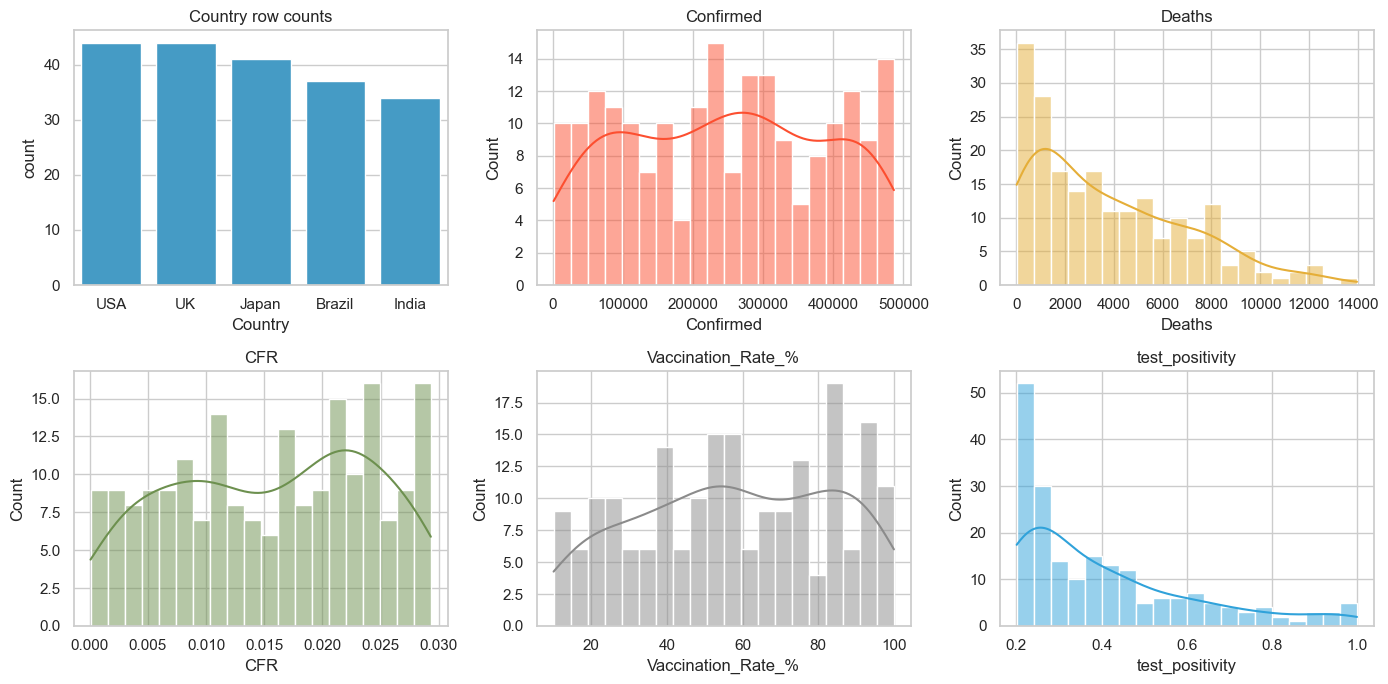

,Confirmed,Deaths,CFR,Vaccination_Rate_%
Country,,,,
Brazil,158812.0,1820.0,0.0136,58.0
India,285353.5,3876.0,0.0147,74.0
Japan,265116.0,2936.0,0.0171,53.0
UK,273882.0,3472.5,0.0171,53.5
USA,255118.5,3003.5,0.0171,59.5


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()
sns.countplot(data=df, x="Country", order=df["Country"].value_counts().index, ax=axes[0], color="#30a2da")
axes[0].set_title("Country row counts")
for ax, col, color in [
    (axes[1], "Confirmed", "#fc4f30"),
    (axes[2], "Deaths", "#e5ae38"),
    (axes[3], "CFR", "#6d904f"),
    (axes[4], "Vaccination_Rate_%", "#8b8b8b"),
    (axes[5], "test_positivity", "#30a2da"),
]:
    sns.histplot(df[col], bins=20, kde=True, ax=ax, color=color)
    ax.set_title(col)
plt.tight_layout()
plt.show()

display(df.groupby("Country")[["Confirmed", "Deaths", "CFR", "Vaccination_Rate_%"]].median().round(4))


**Interpretation** <br>
Row counts are roughly balanced across five countries. Confirmed/deaths are right-skewed; CFR and positivity are the comparable rate views. Country medians already hint that scale differs sharply by geography.


# **4. Faceted Time Series:** <a id="TimeSeries"></a>


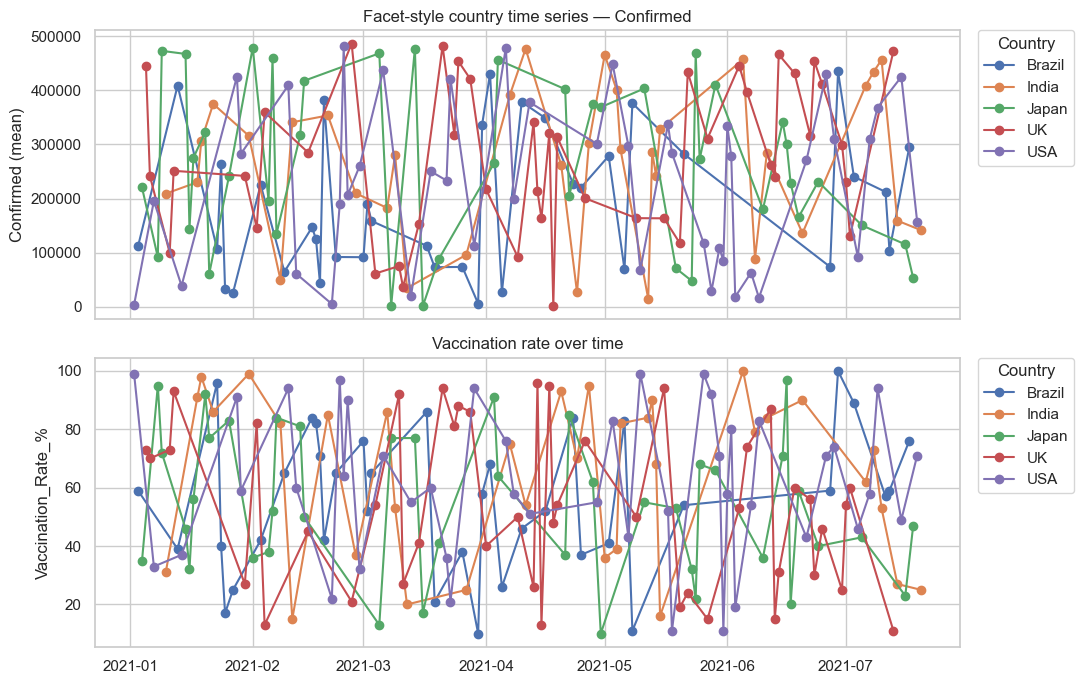

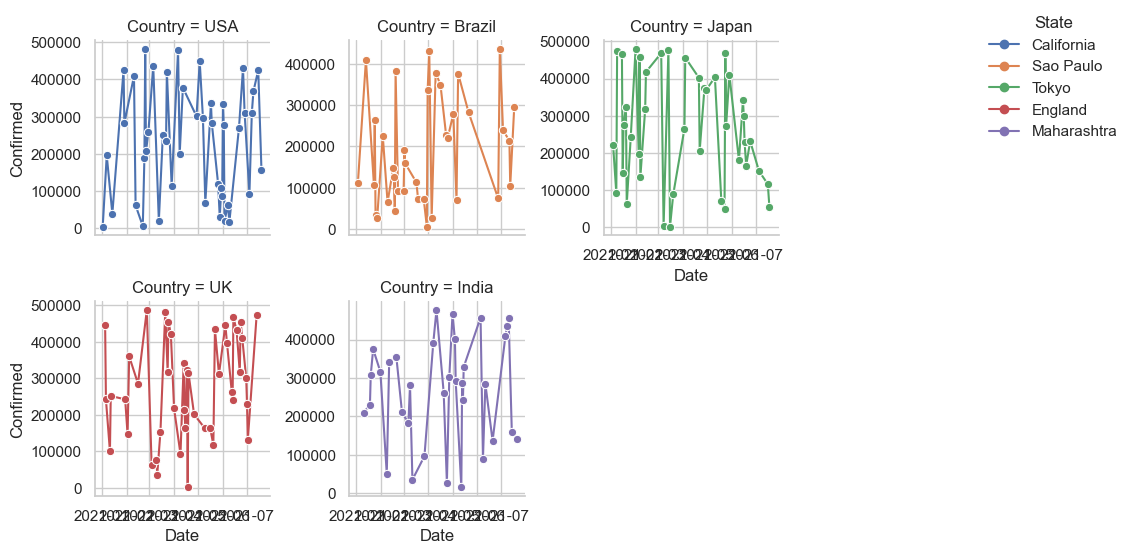

In [4]:
# Country-level daily means (multiple states per date)
ts = df.groupby(["Date", "Country"], as_index=False)[["Confirmed", "Deaths", "Active", "Vaccination_Rate_%"]].mean()

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for country, g in ts.groupby("Country"):
    axes[0].plot(g["Date"], g["Confirmed"], marker="o", label=country)
    axes[1].plot(g["Date"], g["Vaccination_Rate_%"], marker="o", label=country)
axes[0].set_ylabel("Confirmed (mean)")
axes[0].set_title("Facet-style country time series — Confirmed")
axes[0].legend(title="Country", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
axes[1].set_ylabel("Vaccination_Rate_%")
axes[1].set_title("Vaccination rate over time")
axes[1].legend(title="Country", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

g = sns.relplot(
    data=df, x="Date", y="Confirmed", hue="State", col="Country",
    col_wrap=3, kind="line", marker="o", height=2.8, facet_kws={"sharey": False},
)
g.figure.subplots_adjust(right=0.82)
sns.move_legend(g, "upper left", bbox_to_anchor=(1.02, 1))
plt.show()


**Interpretation** <br>
Country aggregates and state facets show whether the panel has real trajectories or scrambled teaching noise. Sharey=False keeps high-burden states from crushing smaller series.


# **5. Vaccination vs Outcomes:** <a id="Vax"></a>


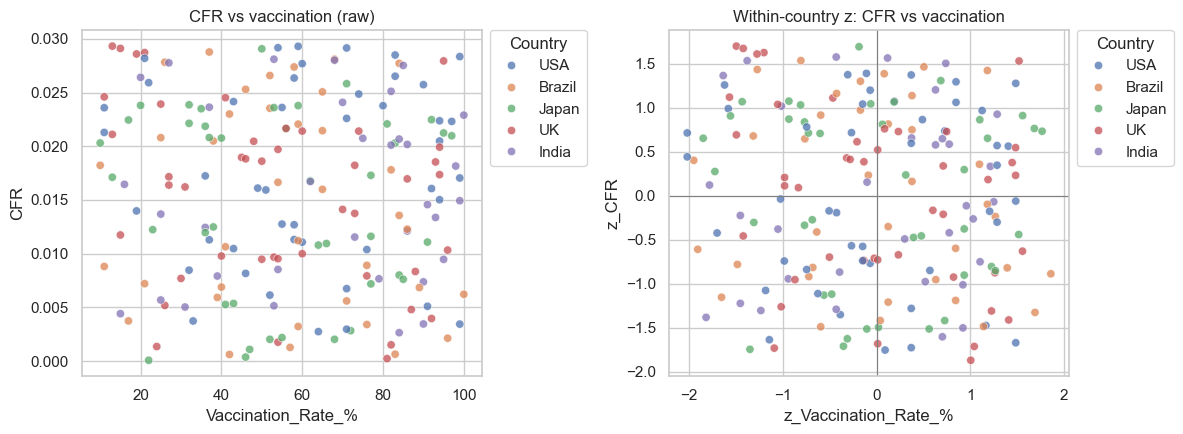

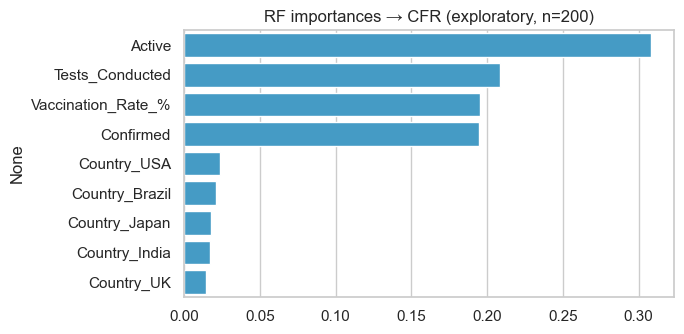

RF in-sample R^2: 0.734


In [5]:
# Raw scatter can be dominated by one high-burden country — also show within-country z-scores
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.scatterplot(
    data=df, x="Vaccination_Rate_%", y="CFR", hue="Country", alpha=0.75, ax=axes[0],
)
axes[0].set_title("CFR vs vaccination (raw)")
axes[0].legend(title="Country", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)

# Within-country z-scores
z = df.copy()
for col in ["Vaccination_Rate_%", "CFR", "Deaths", "Confirmed"]:
    z[f"z_{col}"] = z.groupby("Country")[col].transform(lambda s: (s - s.mean()) / s.std(ddof=0))
sns.scatterplot(
    data=z, x="z_Vaccination_Rate_%", y="z_CFR", hue="Country", alpha=0.75, ax=axes[1],
)
axes[1].axhline(0, color="gray", lw=0.8)
axes[1].axvline(0, color="gray", lw=0.8)
axes[1].set_title("Within-country z: CFR vs vaccination")
axes[1].legend(title="Country", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

# Light RF for CFR
feature_num = ["Confirmed", "Tests_Conducted", "Vaccination_Rate_%", "Active"]
feature_cat = ["Country"]
X = df[feature_num + feature_cat]
y = df["CFR"]
pre = ColumnTransformer([
    ("num", "passthrough", feature_num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), feature_cat),
])
pipe = Pipeline([
    ("pre", pre),
    ("rf", RandomForestRegressor(n_estimators=200, max_depth=8, random_state=7, n_jobs=-1)),
])
pipe.fit(X, y)
rf = pipe.named_steps["rf"]
enc = pipe.named_steps["pre"]
names = feature_num + list(enc.named_transformers_["cat"].get_feature_names_out(feature_cat))
imp = pd.Series(rf.feature_importances_, index=names).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 3.5))
sns.barplot(x=imp.values, y=imp.index, ax=ax, color="#30a2da")
ax.set_title("RF importances → CFR (exploratory, n=200)")
plt.tight_layout()
plt.show()
print("RF in-sample R^2:", round(rf.score(enc.transform(X), y), 3))


**Interpretation** <br>
Raw vax–CFR scatters are easy to misread when one country dominates scale. Within-country z-scores ask whether higher vaccination weeks associate with lower CFR *inside* each country. RF on n=200 is a toy ranking only.


# **6. What It Means — Working Synthesis:** <a id="Synthesis"></a>

**What the table is:** <br>
A 200-row teaching COVID panel across five countries — good for identities and rate practice, not for policy inference.

**Working takeaways:** <br>
- `Active` should equal `Confirmed - Recovered - Deaths`; this file fails that identity on a minority of rows (Active stuck at 0 while the identity goes negative).
- CFR / recovery / positivity are the right normalized views; raw confirmed counts are scale-dominated.
- Faceted state time series reveal whether dates behave like trajectories or scrambled draws.
- Vaccination–outcome plots need within-country z-scores when country scale dominates.
- n=200 and synthetic/teaching construction severely limit external claims.

**Open follow-ups:** <br>
- Repair or flag Active-identity failures before modeling.
- State fixed effects for CFR vs vaccination.
- Whether test positivity mediates the vax–CFR association inside countries.
